In [2]:
import numpy as np
import cv2
import open3d as o3d
import matplotlib.pyplot as plt
from pathlib import Path

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
project_dir = Path("/home/noor/so101-drake")

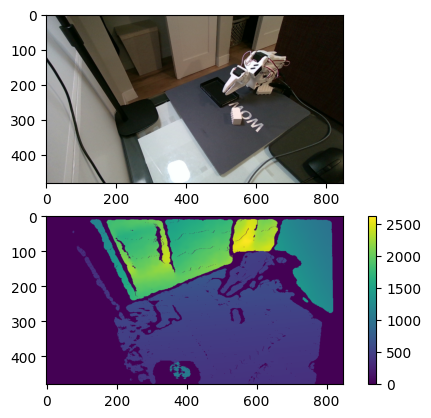

In [3]:
depth_image = np.load(project_dir / "assets" / "test_depth_img.npy")
color_image = cv2.cvtColor(np.load(project_dir / "assets" / "test_color_img.npy"), cv2.COLOR_BGR2RGB)
depth_scale = 0.001

fig, ax = plt.subplots(2, 1)
ax[0].imshow(color_image)
im = ax[1].imshow(depth_image)
fig.colorbar(im, ax=ax[1])

In [4]:
camera_matrix = np.load(project_dir / "assets" / "intrinsics.npy")
extrinsics = np.load(project_dir / "assets" / "cam_to_world.npy")

rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    o3d.geometry.Image(color_image), 
    o3d.geometry.Image(depth_image),
    depth_scale=1/depth_scale,
    depth_trunc=1.0,
    convert_rgb_to_intensity=False,
)

pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    image=rgbd_image,
    intrinsic=o3d.camera.PinholeCameraIntrinsic(
        width=848,
        height=480,
        fx=camera_matrix[0, 0],
        fy=camera_matrix[1, 1],
        cx=camera_matrix[0, 2],
        cy=camera_matrix[1, 2],
    ),
    extrinsic=extrinsics,
    project_valid_depth_only=True
)

o3d.visualization.draw_geometries(
    [pcd],
    up=[0, 0, 1],
    # front=[-0.2, 0.2, 0.2],
    front=[0, 0.2, 0],
    lookat=[0, 0, 0],
)

In [6]:
import pinocchio as pin
from scipy.spatial.transform import Rotation


urdf_path = project_dir / "models" / "SO101" / "so101_new_calib.urdf"

model = pin.buildModelFromUrdf(urdf_path)
collision_model = pin.buildGeomFromUrdf(
    model,
    urdf_path,
    pin.GeometryType.COLLISION,
    package_dirs=[project_dir / "models" / "SO101"]
)

data = model.createData()
collision_data = collision_model.createData()

q_init = np.zeros(6)
q_rest = np.array([0, -1.822, 1.55, 0.906, 0, 0])

pin.forwardKinematics(model, data, q_init)
pin.updateGeometryPlacements(model, data, collision_model, collision_data)

T_world_base = np.eye(4)
rotvec = np.array([0, 0, 1]) * np.pi/2
T_world_base[:3, :3] = Rotation.from_rotvec(rotvec).as_matrix()
T_world_base[:3, 3] = [0, -0.1775, 0.0074]

meshes = []
transforms = []
for i, geom in enumerate(collision_model.geometryObjects):
    T_base_mesh = collision_data.oMg[i]
    T_world_mesh = T_world_base @ T_base_mesh
    transforms.append(T_world_mesh)
    # print(geom.name)
    # print(geom.meshPath)
    # print(T_world_mesh)
    mesh = o3d.io.read_triangle_mesh(geom.meshPath)
    # mesh_t = o3d.t.geometry.TriangleMesh.from_legacy(mesh)
    mesh.transform(T_world_mesh)
    meshes.append(mesh)
    # print(mesh)
    # break
print(len(meshes))

17


In [7]:
pin.forwardKinematics(model, data, q_rest)
pin.updateGeometryPlacements(model, data, collision_model, collision_data)

for i in range(len(collision_model.geometryObjects)):
    T_base_mesh = collision_data.oMg[i]
    T_world_mesh = T_world_base @ T_base_mesh
    meshes[i].transform(np.linalg.inv(transforms[i]))
    meshes[i].transform(T_world_mesh)
    transforms[i] = T_world_mesh

In [8]:
o3d.visualization.draw_geometries(
    [pcd] + meshes,
    up=[0, 0, 1],
    # front=[-0.2, 0.2, 0.2],
    front=[0, 0.2, 0],
    lookat=[0, 0, 0],
)

In [9]:
scene = o3d.t.geometry.RaycastingScene()

for mesh in meshes:
    mesh_t = o3d.t.geometry.TriangleMesh.from_legacy(mesh)
    scene.add_triangles(mesh_t)

pcd_t = o3d.t.geometry.PointCloud.from_legacy(pcd)
signed_distance = scene.compute_signed_distance(pcd_t.point["positions"])
filtered_t = pcd_t.select_by_mask(signed_distance > 0.02)
filtered_t

PointCloud on CPU:0 [129156 points (Float32)].
Attributes: colors (dtype = Float32, shape = {129156, 3}).

In [10]:
filtered = filtered_t.to_legacy()
filtered = filtered.crop(
    o3d.geometry.AxisAlignedBoundingBox(
        min_bound=(-0.19, -0.19, -0.5),
        max_bound=(0.19, 0.19, 0.5),
    )
)

o3d.visualization.draw_geometries(
    [filtered] + meshes,
    up=[0, 0, 1],
    # front=[-0.2, 0.2, 0.2],
    front=[0, 0.2, 0],
    lookat=[0, 0, 0],
)

In [11]:
# Estimate normals
filtered.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(
        radius=0.1, max_nn=30
    )
)
filtered.orient_normals_consistent_tangent_plane(k=15)
filtered.normals = o3d.utility.Vector3dVector(
    -np.asarray(filtered.normals)
)

# Run Poisson reconstruction
mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(filtered, depth=9)

# (Optional) Filter out low-density vertices to remove artifacts
densities = np.asarray(densities)
vertices_to_remove = densities < np.quantile(densities, 0.05) # adjust quantile as needed
mesh.remove_vertices_by_mask(vertices_to_remove)

o3d.visualization.draw_geometries(
    [mesh] + meshes,
    up=[0, 0, 1],
    # front=[-0.2, 0.2, 0.2],
    front=[0, 0.2, 0],
    lookat=[0, 0, 0],
)

In [35]:
# Estimate normals
filtered.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(
        radius=0.1, max_nn=30
    )
)
filtered.orient_normals_consistent_tangent_plane(k=15)

# Define ball radii based on average distances between points
distances = filtered.compute_nearest_neighbor_distance()
avg_dist = np.mean(distances)
radii = [avg_dist, avg_dist * 2]

# Run Ball Pivoting
mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
    filtered, o3d.utility.DoubleVector(radii)
)

o3d.visualization.draw_geometries(
    [mesh] + meshes,
    up=[0, 0, 1],
    # front=[-0.2, 0.2, 0.2],
    front=[0, 0.2, 0],
    lookat=[0, 0, 0],
)

In [91]:
mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(filtered, 0.03)

o3d.visualization.draw_geometries(
    [mesh] + meshes,
    up=[0, 0, 1],
    # front=[-0.2, 0.2, 0.2],
    front=[0, 0.2, 0],
    lookat=[0, 0, 0],
)

In [36]:
o3d.io.write_triangle_mesh(project_dir / "assets" / "mesh.obj", mesh)

[Open3D WARNING] Write OBJ can not include triangle normals.


True

In [37]:
o3d.io.write_point_cloud(project_dir / "assets" / "filtered.ply", filtered)

True